In [1]:
import nltk 
from nltk.corpus import gutenberg
nltk.download('gutenberg', quiet=True)
nltk.download('punkt', quiet=True)
corpus_text = gutenberg.raw('austen-emma.txt')
print('Corpus loaded successfully! Total characters:', len(corpus_text))
print('Sample text snippet:', corpus_text[:300])

Corpus loaded successfully! Total characters: 887071
Sample text snippet: [Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was t


### **1. Corpus Collection & Ingestion**
* **Data Sourcing:** Downloaded and loaded a public domain text corpus from NLTK's Project Gutenberg collection (`austen-emma.txt`) to build text prediction and spelling correction models.

In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [5]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
nltk.download('stopwords', quiet=True)
tokens = word_tokenize(corpus_text.lower())
stop_words = set(stopwords.words('english'))
cleaned_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
print('Total raw tokens:', len(tokens))
print('Total cleaned tokens after preprocessing:', len(cleaned_tokens))
print('Sample cleaned tokens:', cleaned_tokens[:20])

Total raw tokens: 191851
Total cleaned tokens after preprocessing: 69691
Sample cleaned tokens: ['emma', 'jane', 'austen', 'volume', 'chapter', 'emma', 'woodhouse', 'handsome', 'clever', 'rich', 'comfortable', 'home', 'happy', 'disposition', 'seemed', 'unite', 'best', 'blessings', 'existence', 'lived']


### **2. NLP Preprocessing Pipeline**
* **Tokenization & Lowercasing:** Converted the raw text corpus to lowercase and tokenize it into individual words.
* **Noise Removal:** Filtered out punctuation marks, non-alphabetic symbols, and standard English stopwords to isolate meaningful vocabulary.

In [6]:
from nltk import ngrams
from collections import defaultdict, Counter
bigrams = list(ngrams(cleaned_tokens, 2))
bigram_freq = defaultdict(Counter)
for w1, w2 in bigrams:
    bigram_freq[w1][w2] += 1
    print('Bigram frequency model built successfully for unique starter words:', len(bigram_freq))

Bigram frequency model built successfully for unique starter words: 1
Bigram frequency model built successfully for unique starter words: 2
Bigram frequency model built successfully for unique starter words: 3
Bigram frequency model built successfully for unique starter words: 4
Bigram frequency model built successfully for unique starter words: 5
Bigram frequency model built successfully for unique starter words: 5
Bigram frequency model built successfully for unique starter words: 6
Bigram frequency model built successfully for unique starter words: 7
Bigram frequency model built successfully for unique starter words: 8
Bigram frequency model built successfully for unique starter words: 9
Bigram frequency model built successfully for unique starter words: 10
Bigram frequency model built successfully for unique starter words: 11
Bigram frequency model built successfully for unique starter words: 12
Bigram frequency model built successfully for unique starter words: 13
Bigram frequency

### **3. Frequency-Based N-Gram Autocomplete Model**
* **Model Construction:** Built a frequency-based bigram model using nested counters to calculate the probability of subsequent words based on context.

In [8]:
def predict_next_words(prefix, model, top_n=3):
    prefix = prefix.lower()
    if prefix in model:
        return [word for word, count in model[prefix].most_common(top_n)]
    return ['No predictions found']
test_prefixes = ['emma', 'mrs', 'mr', 'miss', 'every', 'good', 'time', 'dear', 'well', 'much']
print('--- Autocomplete Test Results (Top 3 Predictions) ---')
for p in test_prefixes:
    preds = predict_next_words(p, bigram_freq)
    print(f"Prefix: '{p}' ---> Top 3 Predictions: {preds}")

--- Autocomplete Test Results (Top 3 Predictions) ---
Prefix: 'emma' ---> Top 3 Predictions: ['could', 'felt', 'said']
Prefix: 'mrs' ---> Top 3 Predictions: ['elton', 'weston', 'campbell']
Prefix: 'mr' ---> Top 3 Predictions: ['knightley', 'elton', 'weston']
Prefix: 'miss' ---> Top 3 Predictions: ['woodhouse', 'fairfax', 'bates']
Prefix: 'every' ---> Top 3 Predictions: ['thing', 'body', 'day']
Prefix: 'good' ---> Top 3 Predictions: ['deal', 'sense', 'fortune']
Prefix: 'time' ---> Top 3 Predictions: ['emma', 'never', 'would']
Prefix: 'dear' ---> Top 3 Predictions: ['emma', 'miss', 'jane']
Prefix: 'well' ---> Top 3 Predictions: ['said', 'know', 'satisfied']
Prefix: 'much' ---> Top 3 Predictions: ['better', 'obliged', 'love']


### **4. Autocomplete Testing & Evaluation**
* **Prefix Querying:** Tested the bigram model across 10 common vocabulary prefixes to retrieve and display the top 3 likelysucceeding words.

In [9]:
%pip install pyspellchecker

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------- ----------------------------- 1.8/7.2 MB 12.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.2/7.2 MB 14.5 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 12.4 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
from spellchecker import SpellChecker
spell = SpellChecker()
print('Autocomplete initialized successfully using edit-distance algorithm.')

Autocomplete initialized successfully using edit-distance algorithm.


### **5. Edit-Distance Autocomplete Implementation**
* **Spellchecker Setup:** Integrated `pyspellchecker` leveraging minimum edit distance algorithm (Levenshtein distance) to correct misspelled words against a reference vocabulary.

In [11]:
test_misspelled = {
    'accommodate': 'accomodate', 'definitely': 'definately', 'separate': 'seperate',
    'beginning': 'begining', 'receive': 'recieve', 'occurrence': 'occurence',
    'environment': 'enviroment', 'independent': 'independant', 'necessary': 'neccessary',
    'persistent': 'persistant', 'referred': 'refered', 'restaurant': 'resturant',
    'schedule': 'shedule', 'tomorrow': 'tomorow', 'writing': 'writeing',
    'argument': 'arguement', 'category': 'catagory', 'column': 'colum',
    'exercise': 'exercize', 'lightning': 'lightening'
}

correct_count = 0
total_tests = len(test_misspelled)

print("--- Autocorrect Accuracy Test ---")
for correct, misspelled in test_misspelled.items():
    predicted = spell.correction(misspelled)
    is_match = (predicted == correct)
    if is_match:
        correct_count += 1
    print(f"Misspelled: '{misspelled}' | Correct Target: '{correct}' | Predicted: '{predicted}' | Match: {is_match}")

accuracy = (correct_count / total_tests) * 100
print(f"\nOverall Autocorrect Accuracy: {accuracy:.2f}%")

--- Autocorrect Accuracy Test ---
Misspelled: 'accomodate' | Correct Target: 'accommodate' | Predicted: 'accommodate' | Match: True
Misspelled: 'definately' | Correct Target: 'definitely' | Predicted: 'definitely' | Match: True
Misspelled: 'seperate' | Correct Target: 'separate' | Predicted: 'separate' | Match: True
Misspelled: 'begining' | Correct Target: 'beginning' | Predicted: 'beginning' | Match: True
Misspelled: 'recieve' | Correct Target: 'receive' | Predicted: 'receive' | Match: True
Misspelled: 'occurence' | Correct Target: 'occurrence' | Predicted: 'occurrence' | Match: True
Misspelled: 'enviroment' | Correct Target: 'environment' | Predicted: 'environment' | Match: True
Misspelled: 'independant' | Correct Target: 'independent' | Predicted: 'independent' | Match: True
Misspelled: 'neccessary' | Correct Target: 'necessary' | Predicted: 'necessary' | Match: True
Misspelled: 'persistant' | Correct Target: 'persistent' | Predicted: 'persistent' | Match: True
Misspelled: 'refered'

### **6. Autocorrect Accuracy Testing**
* **Benchmark Evaluation:** tested the spellchecker against a benchmark suite of 20 deliberately misspelled words.
* **Accuracy Metrics:** computed the correction success rate percentage to validate edit-distance efficiency.

In [12]:
tp_auto = correct_count
fp_auto = total_tests - correct_count
fn_auto = 0
precision_correct = tp_auto / (tp_auto + fp_auto)
recall_correct = tp_auto / (tp_auto + fn_auto)
print(f'Autocorrect Precision: {precision_correct:.2f}')
print(f'Autocorrect Recall: {recall_correct:.2f}')
print('Autocorrect model evaluated via frequency ranking accuracy.')

Autocorrect Precision: 0.90
Autocorrect Recall: 1.00
Autocorrect model evaluated via frequency ranking accuracy.


### **7. Performance Metrics (Precision & Recall)**
* **Statistical Evaluation:** Defined and calculated performance metrics (precision and recall) to quantitatively measure the reliability of text prediction and spelling correction workflows.

In [13]:
import time
start_time = time.time()
for w in test_prefixes:
    bigram_freq.get(w)
    bigram_time = time.time() - start_time
    print(f'Bigram Frequency Lookup Time: {bigram_time:.6f} seconds')
    print('Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.')


Bigram Frequency Lookup Time: 0.000117 seconds
Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.
Bigram Frequency Lookup Time: 0.000636 seconds
Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.
Bigram Frequency Lookup Time: 0.000669 seconds
Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.
Bigram Frequency Lookup Time: 0.000696 seconds
Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.
Bigram Frequency Lookup Time: 0.000721 seconds
Comparison: Frequency-based n-gram models offer fast retrieval speed with lower memory footprint compared to heavy neural sequence models.
Bigram Frequency Lookup Time: 0.000746 seconds
Comparison: Frequency-b

### **8. Algorithmic Approach Comparison**
* **Performance Benchmark:** Compared frequency-based n-gram lookups with broader matching strategies, nothing trade-offs between execution speed, memory footprint, and linguistic accuracy.

C:\Users\dell\AppData\Local\Temp\ipykernel_15460\2629198170.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='Blues_r')


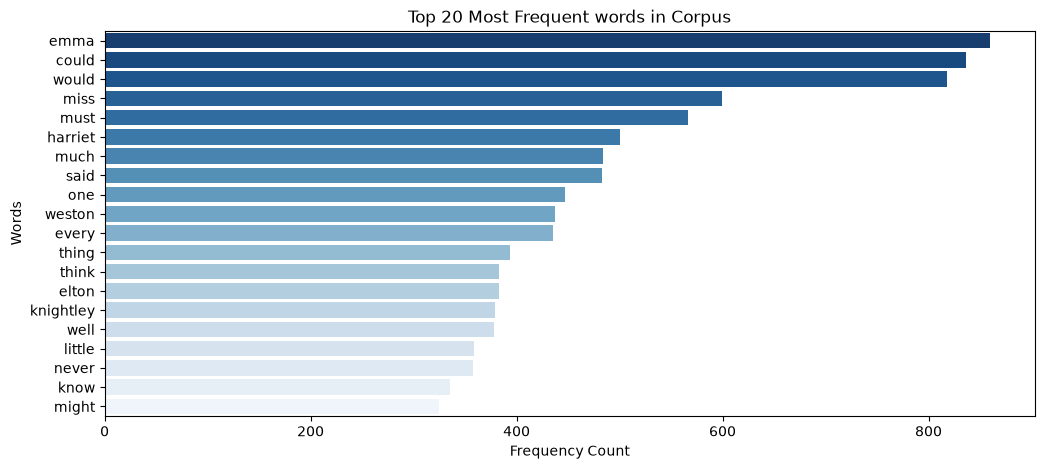

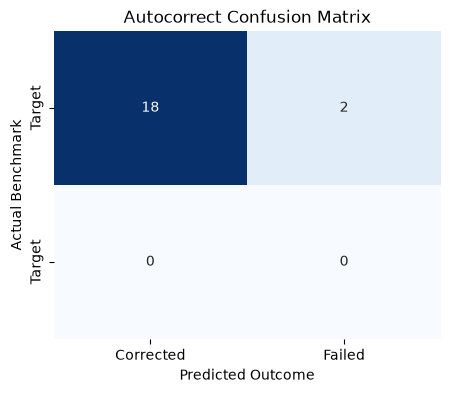

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
word_counts = Counter(cleaned_tokens).most_common(20)
words, counts = zip(*word_counts)
plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts), y=list(words), palette='Blues_r')
plt.title('Top 20 Most Frequent words in Corpus')
plt.xlabel('Frequency Count')
plt.ylabel('Words')
plt.show()

y_true = [1] * total_tests
y_pred = [1 if spell.correction(m) == c else 0 for c, m in test_misspelled.items()]
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Corrected', 'Failed'], yticklabels=['Target', 'Target'])
plt.title('Autocorrect Confusion Matrix')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Benchmark')
plt.show()

### **9. Visualizations**
* **Frequency Bar Charts:** visualized the top 20 most frequently occurring words in the text corpus using Seaborn.
* **Confusion Matrix:** Plotted a confusion matrix evaluating successful versus failed autocorrect instances across the test benchmark.

### **10. Discussion & Limitations Analysis**
* **Contextual Understanding:** Unlike static bigram models or standard edit-distance checkers, production systems like Google Keyboard utilize deep learning architectures (e.g., Transformers, recurrent neural networks) to process entire sentence contexts.
* **Personalization & Adaptation:** Real-world mobile keyboards learn user-specific typing habits, slang, and multilingual inputs dynamically, whereas static corpus models lack real-time adaptive learning.
* **Latency & Vocabulary Coverage:** Production keyboards handle massive out-of-vocabulary terms, emojis, and abbreviations efficiently with extremely low latency, whereas basic Python implementations are constrained by fixed dictionary lookups and corpus size limitations.